# 03 · What EO inputs recover under weak labels: the U-Net arm experiments

Controlled experiments on flood-state representation under weak, sensor-dependent supervision. U2b (+W_pre) is a diagnostic upper bound: W_pre is also a label ingredient.

**Reading rules.** Every model number is *agreement with weak reference labels*, never flood-mapping accuracy. "Not observed is not dry." Areas carry their semantics (observed_S1 / mapped_UNet / terrain_reconstructed / literature_reported). Evidence levels: independent_physical › cross_sensor › weak_label_agreement › contextual.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "case_studies/kakhovka_2023/tables").exists())
CS = ROOT / "case_studies/kakhovka_2023"; T = CS / "tables"; PT = CS / "publication/tables"; PF = CS / "publication/figures"; RUNS = CS / "runs"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
C = {"terrain": "#2a78d6", "s1": "#eb6834", "unet": "#4a3aa7", "rf": "#1baf7a", "gauge": "#52514e"}
def show(tid, n=None):
    df = pd.read_csv(PT / f"{tid}.csv"); cap = json.loads((PT / "manifest.json").read_text())["tables"][tid]
    display(Markdown(f"**{tid}** [{cap['evidence_level']}] {cap['caption']}")); return df.head(n) if n else df
def fig(name): p = next(PF.glob(name + "*.png"), None); display(Image(str(p), width=900)) if p else print("figure not rendered yet:", name)
print("repo:", ROOT)

repo: /home/niko/repo/floodstate-eo


## 1. Labels v002 and v003_A (frozen)

In [2]:
show('T02'); show('T02b')

**T02** [weak_label_agreement] Weak reference labels per frame, km2: v002 (FLOOD / NON_FLOOD / IGNORE) and v003_A (LAND / EVENT_FLOOD / REFERENCE_WATER / UNKNOWN), built on the original M2 (with the post-event TRACE window, in-sample threshold; frozen history), and v002_notrace and v004, the same rules on the corrected M2 (no TRACE, out-of-fold threshold; review F09/F10). EVENT_FLOOD is pixel-identical to the FLOOD of the v002 version it inherits.

**T02b** [weak_label_agreement] Transition v002 -> v003_A and v002_notrace -> v004 per frame, km2 (the v003 rule changes the negative side and the UNKNOWN domain).

,labels,frame,v002,EVENT_FLOOD,LAND,REFERENCE_WATER,UNKNOWN
0,v002 -> v003_A,B1,FLOOD,128.90,0.00,0.00,0.00
1,v002 -> v003_A,B1,IGNORE,0.00,0.00,250.79,3958.88
2,v002 -> v003_A,B1,NON_FLOOD,0.00,1544.30,7.68,201.12
3,v002 -> v003_A,B2,FLOOD,57.49,0.00,0.00,0.00
4,v002 -> v003_A,B2,IGNORE,0.00,0.00,280.06,1812.21
5,v002 -> v003_A,B2,NON_FLOOD,0.00,663.09,3.79,69.28
6,v002_notrace -> v004,B1,FLOOD,141.92,0.00,0.00,0.00
7,v002_notrace -> v004,B1,IGNORE,0.00,0.00,250.17,3979.28
8,v002_notrace -> v004,B1,NON_FLOOD,0.00,1513.71,7.58,199.02
9,v002_notrace -> v004,B2,FLOOD,75.15,0.00,0.00,0.00


## 2. The frozen spatial-block split and its rationale

In [3]:
show('T03'); show('T03b')

**T03** [weak_label_agreement] Frozen spatial-block split m6_split_v1: geometry, counts and rationale.

**T03b** [weak_label_agreement] Stratum shares of the frozen split (train / validation / test), km2.

,stratum,total_km2,train_share,val_share,test_share,train_km2,val_km2,test_km2
0,DRY_CROPLAND,1019.01,0.506,0.126,0.368,515.60,128.62,374.78
1,FLOODED_OPEN_LOW_VEGETATION,20.12,0.503,0.167,0.330,10.13,3.35,6.64
2,FLOODED_WETLAND,127.80,0.561,0.101,0.338,71.70,12.91,43.20
3,DRY_WETLAND_OR_VEGETATION,859.73,0.597,0.164,0.239,512.88,141.40,205.46
4,FLOOD_BOUNDARY,13.24,0.626,0.088,0.285,8.29,1.17,3.78
5,FLOODED_CROPLAND,3.10,0.594,0.160,0.246,1.84,0.50,0.76


## 3. Arms

In [4]:
show('T04')

**T04** [weak_label_agreement] U-Net arms: inputs, labels, frozen validation threshold and training settings. U2b is a diagnostic experiment (W_pre is also a label ingredient).

,arm,labels,run,n_channels,channels,note,threshold,val_F1,epochs,batch,lr,seed,seconds,diagnostic_only
0,U0d,v002,U0d_B1B2_v1,12,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"S1 d_* + support + has_event. NO z_*, NO p73, ...",0.56,0.8998,60,6,0.0003,20260923,131,False
1,U0z,v002,U0z_B1B2_v1,16,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,U0d + robust z_* (domain-shift ablation).,0.59,0.9179,60,6,0.0003,20260923,187,False
2,U1,v002,U1_B1B2_v1,20,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,U0d + frozen p73 RF20 surface class as one-hot...,0.31,0.9271,60,6,0.0003,20260923,196,False
3,U2,v002,U2_B1B2_v1,14,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"U0d + HAND (floodplain/<zone>_hand_m.tif, metr...",0.50,0.9109,60,6,0.0003,20260923,178,False
4,U0d,v003_A,U0d_B1B2_v003A,12,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"S1 d_* + support + has_event. NO z_*, NO p73, ...",0.65,0.8955,60,6,0.0003,20260923,180,False
5,U2,v003_A,U2_B1B2_v003A,14,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"U0d + HAND (floodplain/<zone>_hand_m.tif, metr...",0.37,0.8786,60,6,0.0003,20260923,182,False
6,U2b,v003_A,U2b_B1B2_v003A,16,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,U2 + W_pre (S1 06-01/06-02 water state) + has_...,0.78,0.9047,60,6,0.0003,20260923,189,True
7,U0d,v004,U0d_B1B2_v004,12,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"S1 d_* + support + has_event. NO z_*, NO p73, ...",0.17,0.8596,60,6,0.0003,20260923,183,False
8,U0d,v004,U0d_B1B2_v004_s20261001,12,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"S1 d_* + support + has_event. NO z_*, NO p73, ...",0.20,0.8842,60,6,0.0003,20261001,183,False
9,U0d,v004,U0d_B1B2_v004_s20261002,12,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"S1 d_* + support + has_event. NO z_*, NO p73, ...",0.36,0.8562,60,6,0.0003,20261002,181,False


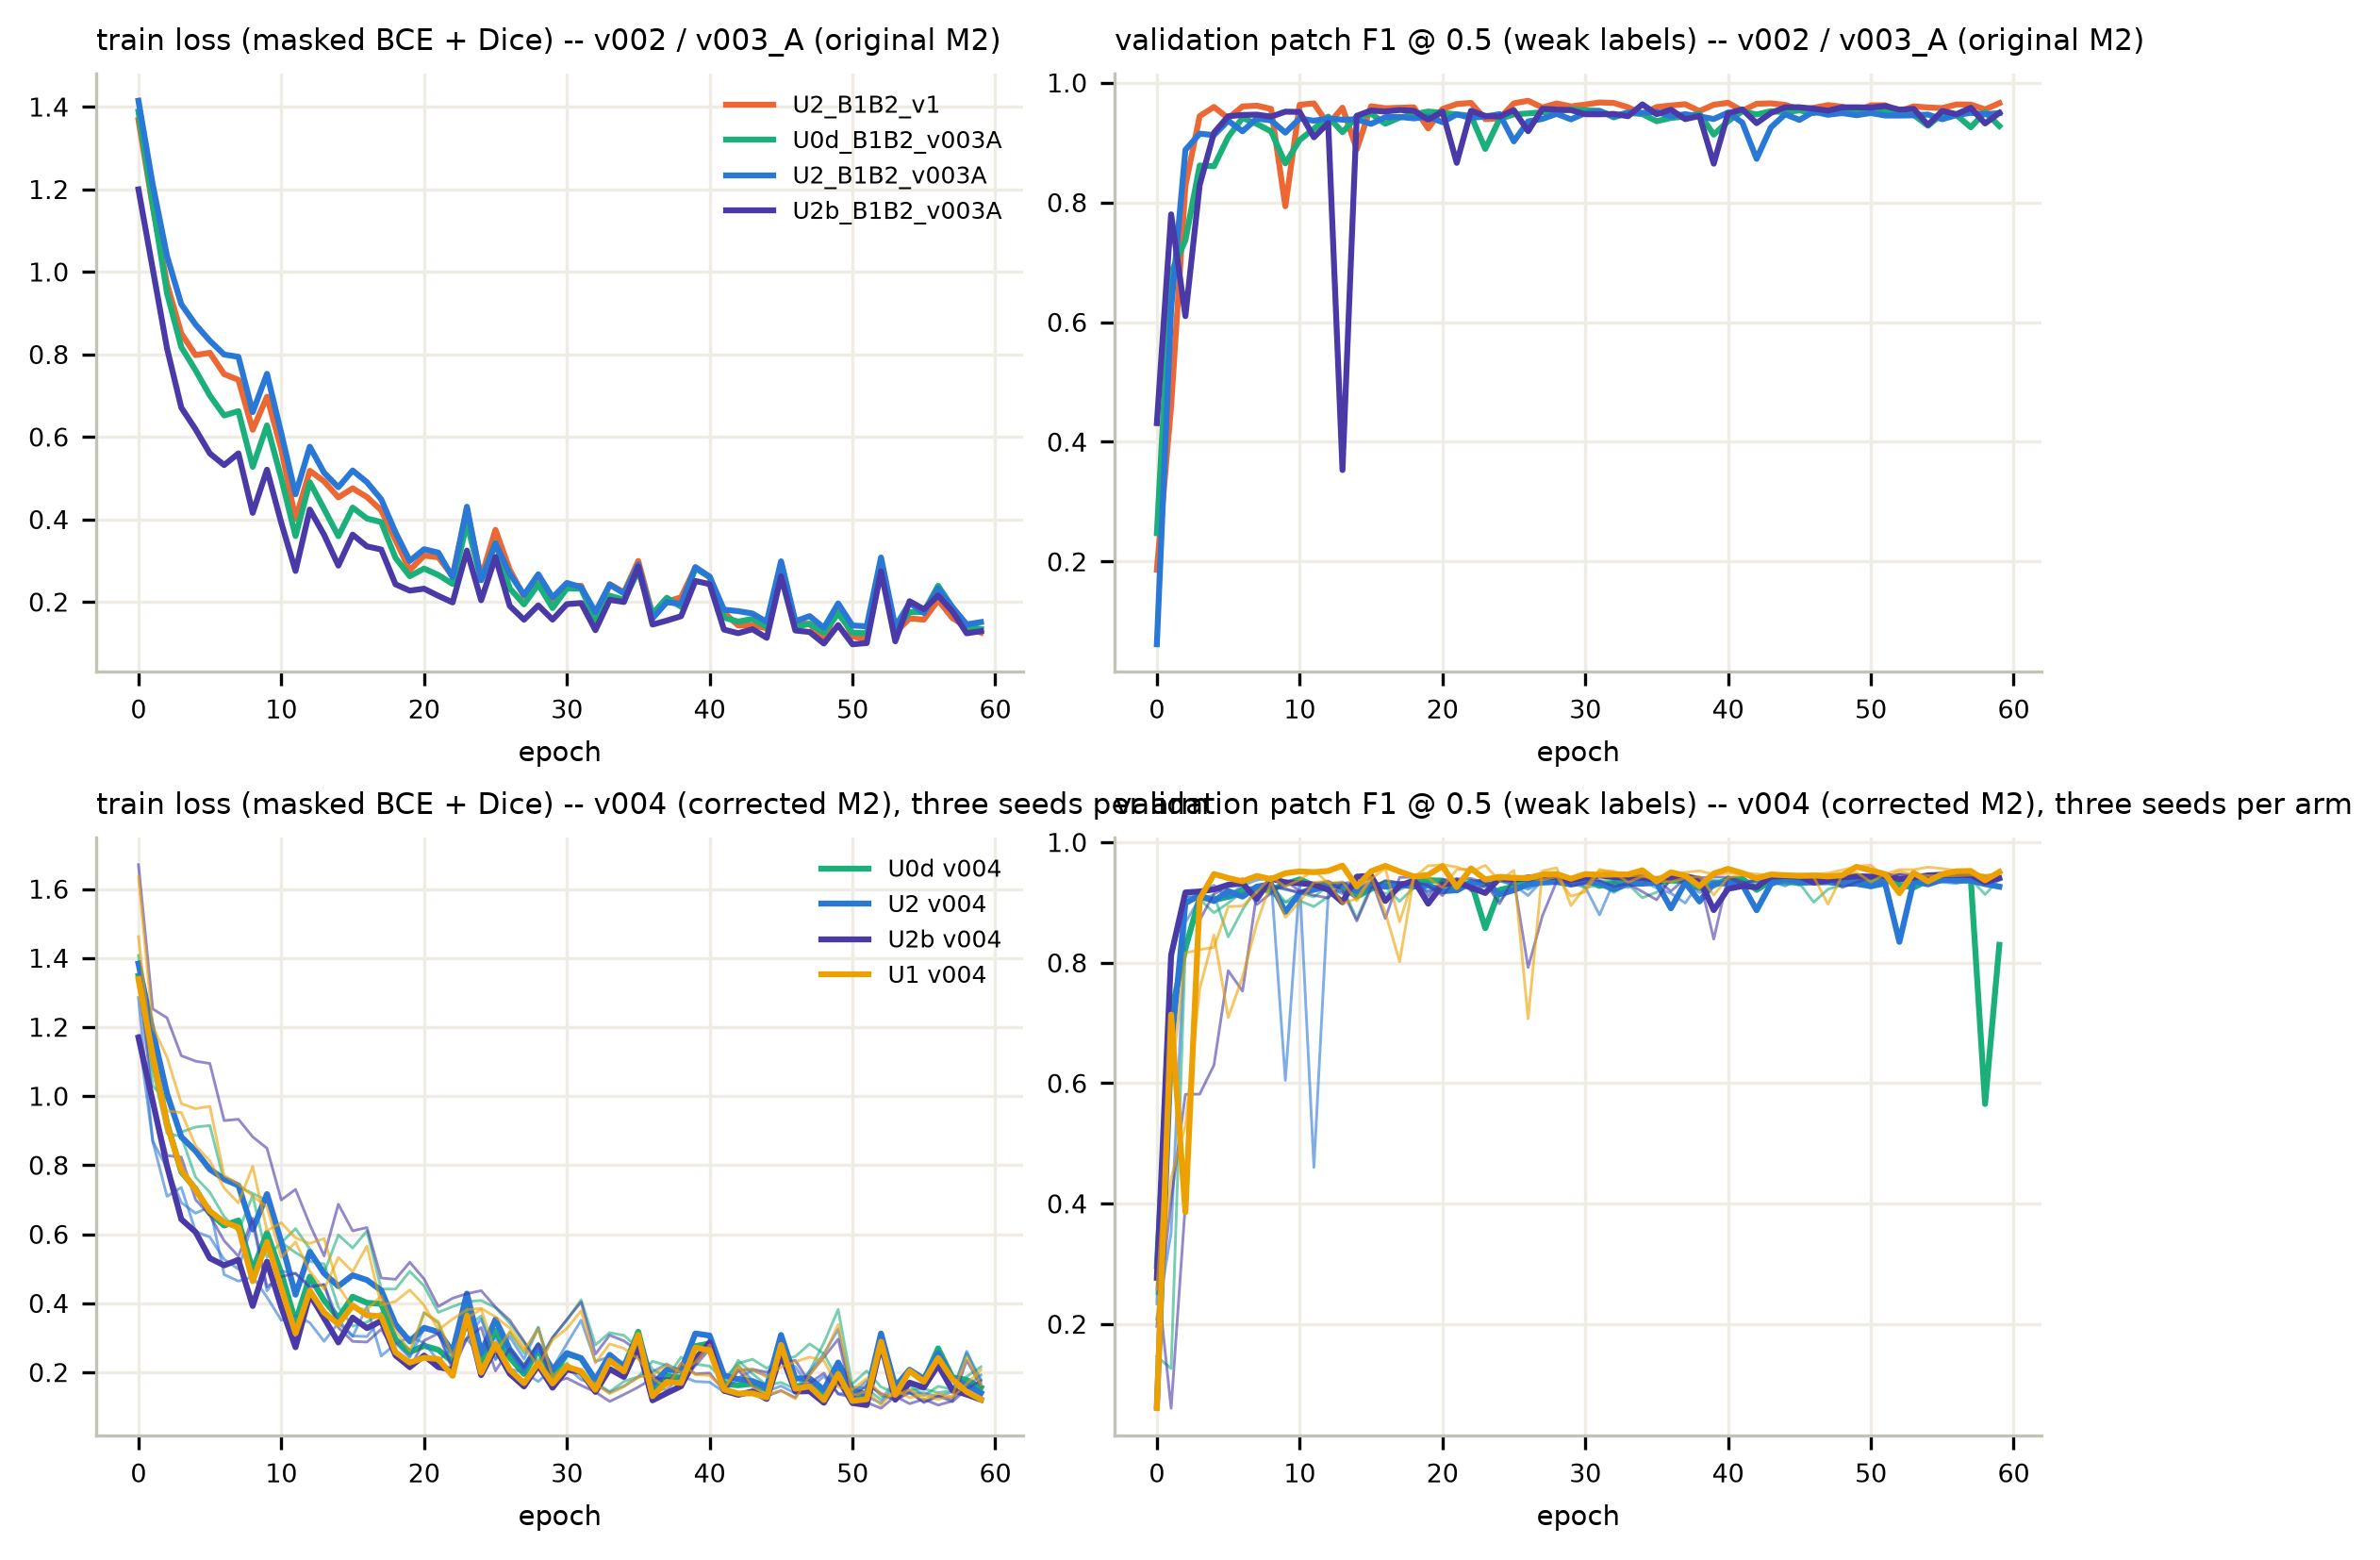

In [5]:
fig('FigS01')

## 4. D1 endpoints with spatial-block bootstrap intervals

In [6]:
e = show('T05'); e[e.endpoint.isin(['G_F1','G_IoU','G_PR_AUC','A_FP_area_dry_cropland_km2','A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLAND_km2','B_recall_flooded_open_low_veg','W_IoU','BU_FP_area_km2'])].pivot_table(index=['arm','labels'], columns='endpoint', values='value')

**T05** [weak_label_agreement] D1 endpoints per arm on the frozen TEST blocks with 95 % spatial-block bootstrap intervals (2000 resamples; n_defined = resamples in which the endpoint is defined, review F11). v004 arms are trained with three seeds (run suffix _s<seed>; the first seed has no suffix).

endpoint          A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLAND_km2  A_FP_area_dry_cropland_km2  BU_FP_area_km2  B_recall_flooded_open_low_veg      G_F1     G_IoU  G_PR_AUC     W_IoU
arm labels                                                                                                                                                                               
U0d v002                                                  21.208400                       0.548800        0.386400                       0.733000  0.945200  0.896100  0.980700  0.957000
    v003_A                                                 7.560300                       0.430600        0.369200                       0.690100  0.928700  0.866900  0.969800  0.935500
    v004                                                   7.654100                       0.693633        0.449833                       0.626233  0.927500  0.864867  0.960200  0.952433
U0z v002                                                  17.352300                       0.125800        0.205500                       0.713400  0.953300  0.910800  0.981600  0.958800
U1  v002                                                  23.922000                       0.609100        0.055300                       0.840400  0.962200  0.927200  0.988800  0.968900
    v004                                                  26.312600                       1.620700        0.116033                       0.706933  0.931400  0.871700  0.960267  0.955000
U2  v002                                                  11.680000                       0.115300        0.804700                       0.776400  0.937500  0.882300  0.978000  0.948400
    v002_notrace                                          24.397600                       1.743967        0.764567                       0.676867  0.920567  0.852933  0.971767  0.952667
    v003_A                                                 4.062500                       0.156000        0.297500                       0.645800  0.930600  0.870200  0.961300  0.945600
    v004                                                   9.222067                       0.627500        0.423400                       0.645867  0.932867  0.874100  0.965167  0.959167
U2b v003_A                                                 1.467200                       0.066200        0.492200                       0.691700  0.936500  0.880500  0.972400  0.948600
    v004                                                   1.734367                       0.202833        0.725433                       0.650200  0.908033  0.832567  0.963433  0.947067

## 5. Paired comparisons (identical blocks)

In [7]:
p = show('T06'); p[p.endpoint.isin(['A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLAND_km2','B_recall_flooded_open_low_veg','G_F1','BU_FP_area_km2'])]

**T06** [weak_label_agreement] Paired arm comparisons (B minus A) on identical spatial blocks, 2000 resamples, 95 % intervals; v004 per training seed (both arms of a pair share the seed).

,comparison,labels,seed,endpoint,median,ci_lo,ci_hi,excludes_zero,n_defined,independent,note
3,U0z - U0d,v002,NaN,B_recall_flooded_open_low_veg,-0.01860,-0.042900,0.000200,False,NaN,weak-label,NaN
13,U0z - U0d,v002,NaN,BU_FP_area_km2,-0.17670,-0.457618,-0.003300,True,NaN,weak-label,NaN
16,U0z - U0d,v002,NaN,G_F1,0.00765,0.000600,0.060902,True,NaN,weak-label,NaN
22,U0z - U0d,v002,NaN,A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLA...,-3.74535,-9.932835,2.249097,False,NaN,weak-label,NaN
31,U1 - U0d,v002,NaN,B_recall_flooded_open_low_veg,0.10575,0.005698,0.371602,True,NaN,weak-label,NaN
41,U1 - U0d,v002,NaN,BU_FP_area_km2,-0.32120,-0.831800,-0.006300,True,NaN,weak-label,NaN
44,U1 - U0d,v002,NaN,G_F1,0.01650,-0.006702,0.025100,False,NaN,weak-label,NaN
50,U1 - U0d,v002,NaN,A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLA...,2.59915,-1.916290,9.323620,False,NaN,weak-label,NaN
59,U2 - U0d,v002,NaN,B_recall_flooded_open_low_veg,0.04280,-0.005100,0.175900,False,NaN,weak-label,NaN
69,U2 - U0d,v002,NaN,BU_FP_area_km2,0.37005,0.038398,1.025718,True,NaN,weak-label,NaN


In [8]:
show('T07b')

**T07b** [weak_label_agreement] Paired differences (B minus A) of the attribution endpoints across label sets, inputs and (v004) training seeds.

,A,B,endpoint,median,lo,hi,labels,n_defined,excludes_zero,independent
0,U2_B1B2_v1,U2_B1B2_v003A,R_pred_on_reference_water_km2,-13.41275,-29.52655,-2.45226,v003_A,NaN,True,weak-label
1,U2_B1B2_v1,U2_B1B2_v003A,R_pred_on_reference_water_wpre_water_km2,-13.08275,-29.18553,-2.39700,v003_A,NaN,True,weak-label
2,U2_B1B2_v1,U2_B1B2_v003A,R_pred_on_reference_water_wpre_dry_km2,-0.25490,-0.71302,-0.01640,v003_A,NaN,True,weak-label
3,U2_B1B2_v1,U2_B1B2_v003A,R_frac_reference_water_above_thr,-0.09737,-0.14481,-0.02741,v003_A,NaN,True,weak-label
4,U2_B1B2_v1,U2_B1B2_v003A,R_reference_water_evaluated_km2,0.00000,0.00000,0.00000,v003_A,NaN,False,weak-label
...,...,...,...,...,...,...,...,...,...,...
151,U0d_B1B2_v004_s20261002,U2_B1B2_v004_s20261002,L_FP_on_land_km2,-0.94775,-2.40337,0.04702,v004,2000.0,False,weak-label
152,U0d_B1B2_v004_s20261002,U2_B1B2_v004_s20261002,L_FP_rate_land,-0.00202,-0.00549,0.00011,v004,2000.0,False,weak-label
153,U0d_B1B2_v004_s20261002,U2_B1B2_v004_s20261002,L_evaluated_km2,0.00000,0.00000,0.00000,v004,2000.0,False,weak-label
154,U0d_B1B2_v004_s20261002,U2_B1B2_v004_s20261002,U_pred_on_unknown_km2,-5.05355,-11.09856,0.06324,v004,2000.0,False,weak-label


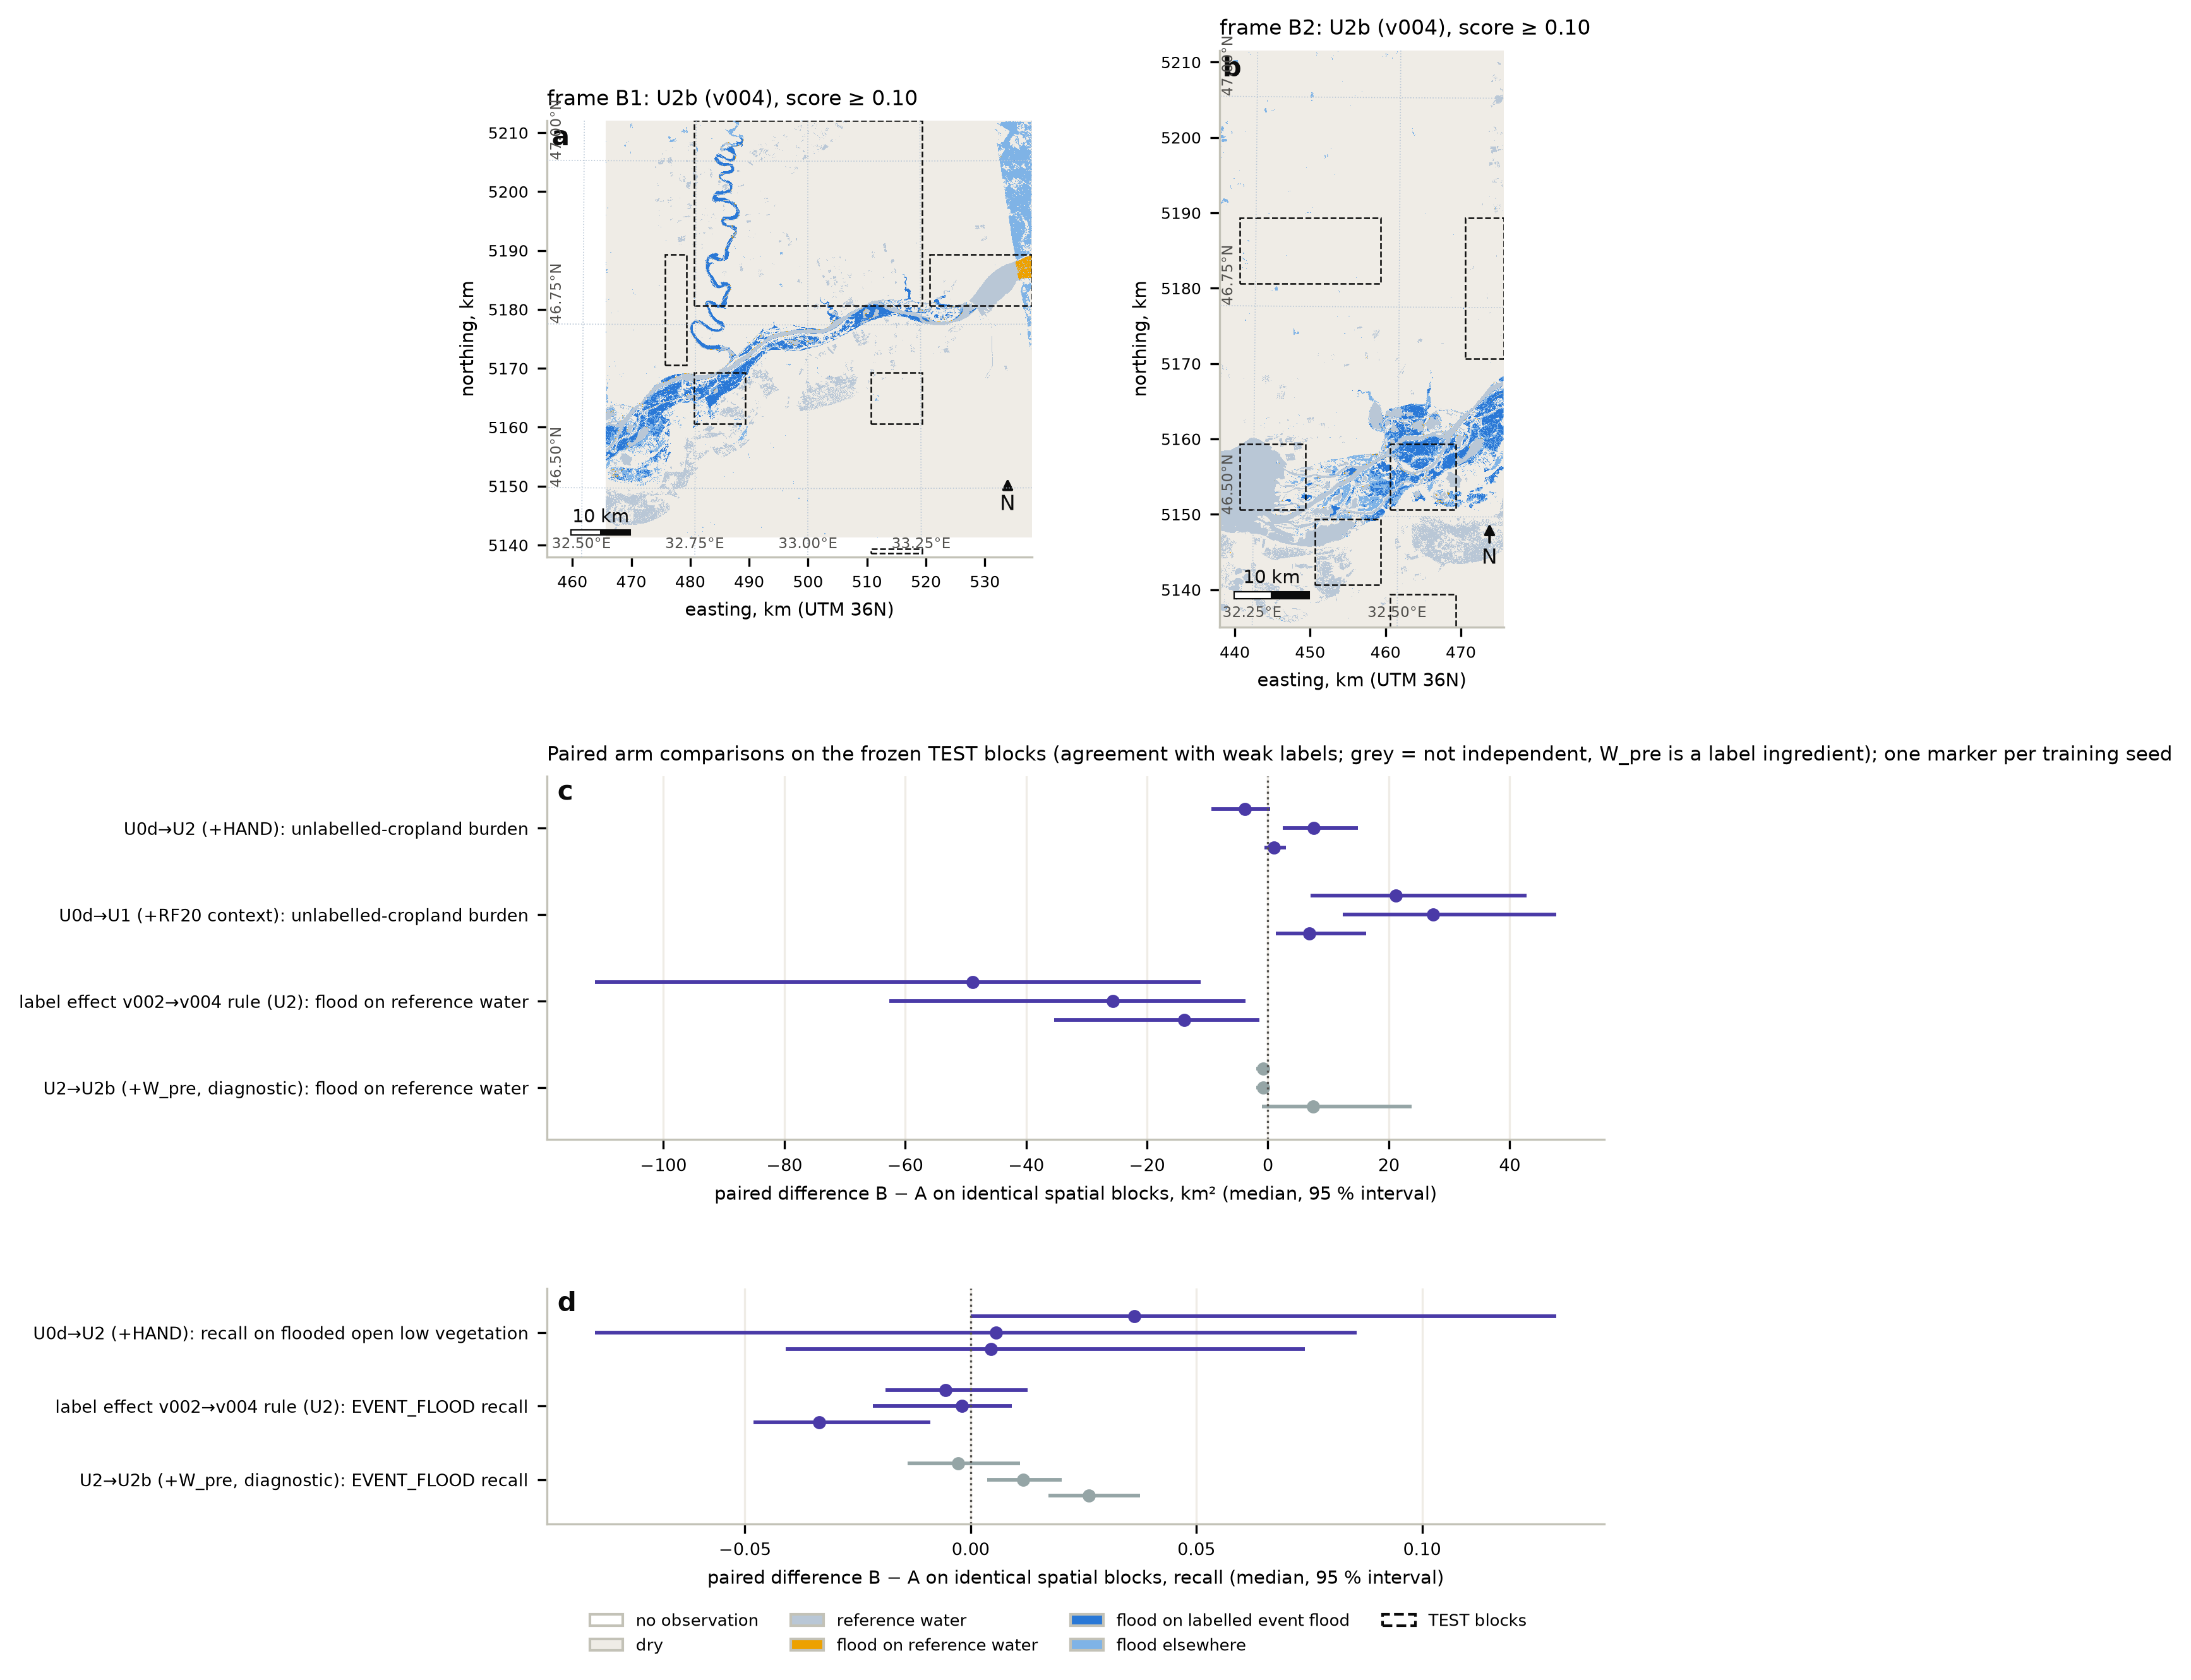

In [9]:
fig('Fig03')

## 6. Cropland-associated SAR candidates (audit)
Wording rule: none of the audited candidates showed positive evidence consistent with breach-induced inundation under the available SAR, optical and terrain constraints.

In [10]:
show('T08'); show('T08b')

**T08** [weak_label_agreement] Cropland-associated SAR candidates (p89 audit): groups A (water before the breach), B (wet/irrigated agriculture), D (unresolved / likely SAR artefact) per arm and frame.

**T08b** [weak_label_agreement] Retention of U0d candidate area by the other v002 arms (fraction of km2).

,group,U0d_area_km2,retained_km2_U0z,retained_km2_U1,retained_km2_U2,retention_U0z,retention_U1,retention_U2
0,A,7.292,2.963,5.687,3.156,0.406,0.780,0.433
1,B,8.020,5.684,6.838,4.373,0.709,0.853,0.545
2,D,3.865,3.366,3.525,2.143,0.871,0.912,0.555


## 7. Block-size sensitivity

**T20** [weak_label_agreement] Block-size sensitivity (U2 on v003_A and on the corrected v004 labels): the same recipe on splits with 7.5, 10 (frozen), 15 and 20 km blocks; each split has its own TEST geography, so only the endpoint values and intervals are compared, never differences.

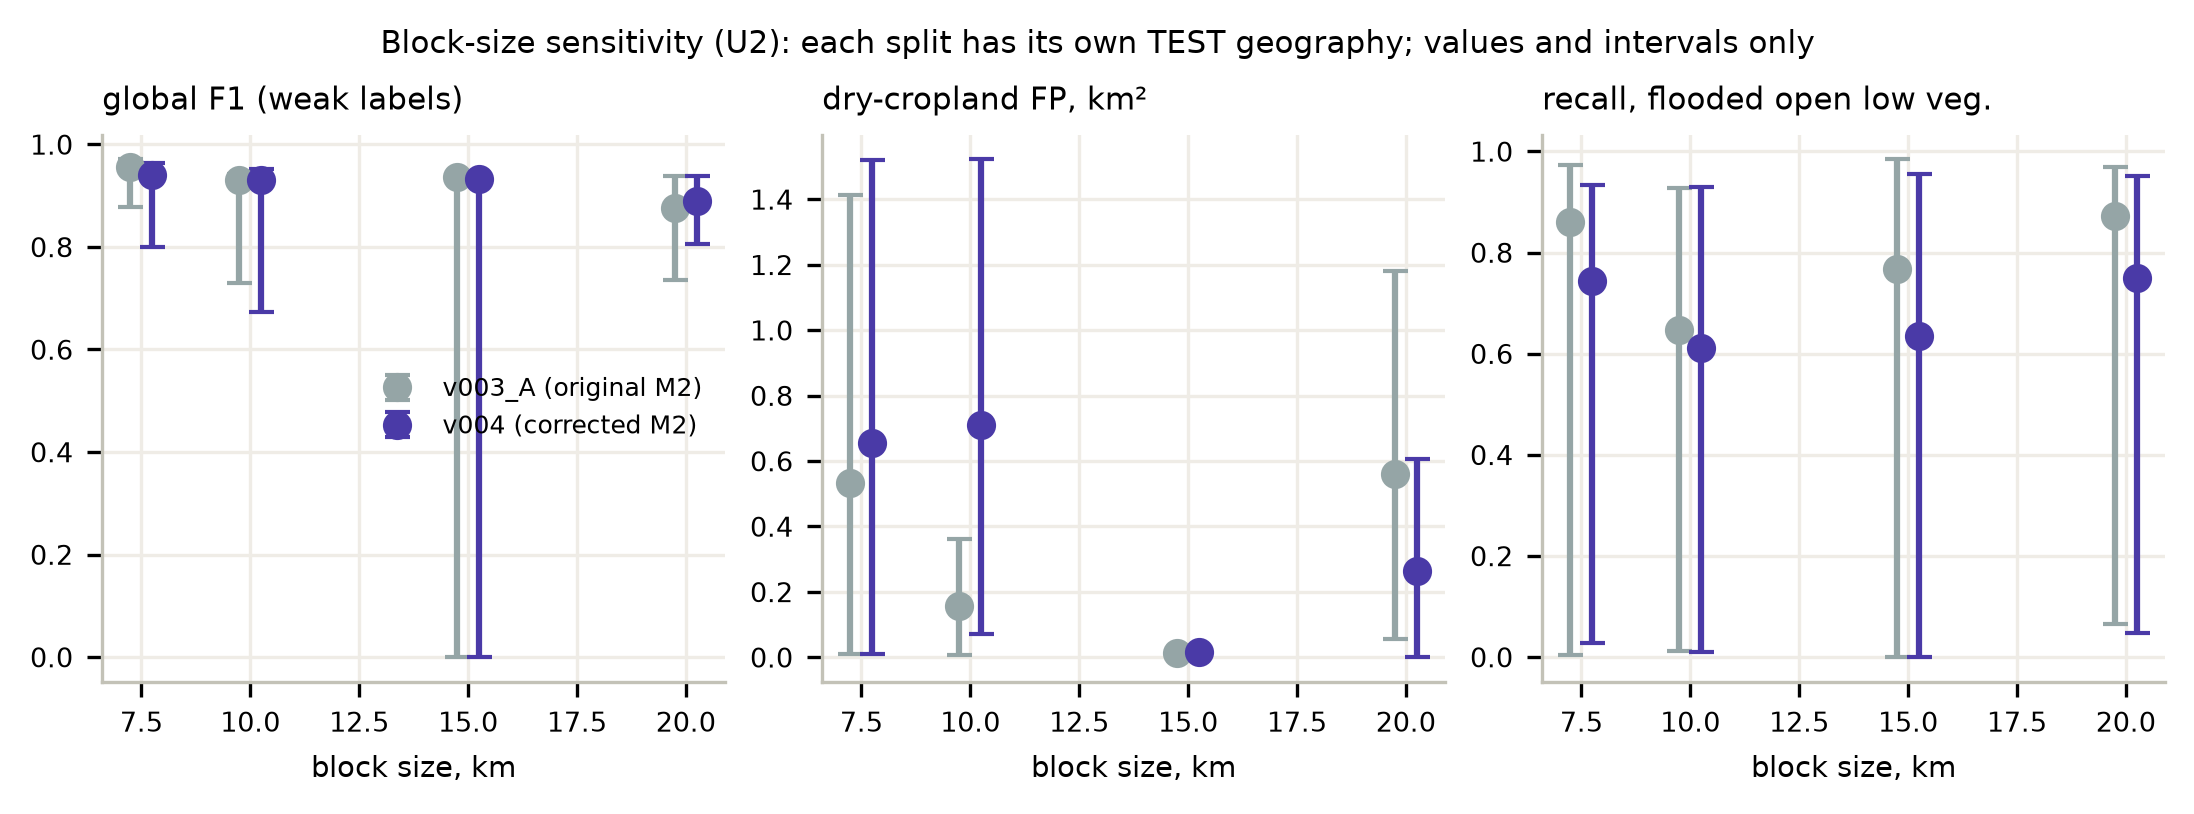

In [11]:
show('T20'); fig('FigS05')